In [1]:
import joblib
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
#Loading and reading the file.
insurance = pd.read_csv('insurance.csv')

In [3]:
#Creating a copy of the dataset.
insurance_copy = insurance.copy()

In [4]:
#View of the dataset.
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
#insurance[insurance.duplicated().sum()] #How to show the duplicate values rows. Also check how to show missing value rows.

In [7]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
#Renaming the columns name.
insurance.columns= ['Age','Sex','BMI','Children','Smoker','Region','Charges']

In [9]:
insurance['Charges'] = insurance['Charges'].round(2)

In [10]:
#Feature Engineering: Categorical conversion.
insurance['Region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

In [11]:
#One-hot for encoding for region. drop_first=True prevents the 'dummy variable trap' by removing one redundant column(I've issue with this drop-first, it removes one column I think is important).
insurance = pd.get_dummies(insurance, columns=['Region'])

In [12]:
#Binary mappings
insurance['Sex'] = insurance['Sex'].map({'female':1,'male':0})

insurance['Smoker'] = insurance['Smoker'].map({'no':0,'yes':1})

In [13]:
#Rearrange the columns.

In [14]:
insurance

,Age,Sex,BMI,Children,Smoker,Charges,Region_northeast,Region_northwest,Region_southeast,Region_southwest
0,19,1,27.900,0,1,16884.92,False,False,False,True
1,18,0,33.770,1,0,1725.55,False,False,True,False
2,28,0,33.000,3,0,4449.46,False,False,True,False
3,33,0,22.705,0,0,21984.47,False,True,False,False
4,32,0,28.880,0,0,3866.86,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.55,False,True,False,False
1334,18,1,31.920,0,0,2205.98,True,False,False,False
1335,18,1,36.850,0,0,1629.83,False,False,True,False
1336,21,1,25.800,0,0,2007.94,False,False,False,True


<Figure size 1500x800 with 0 Axes>

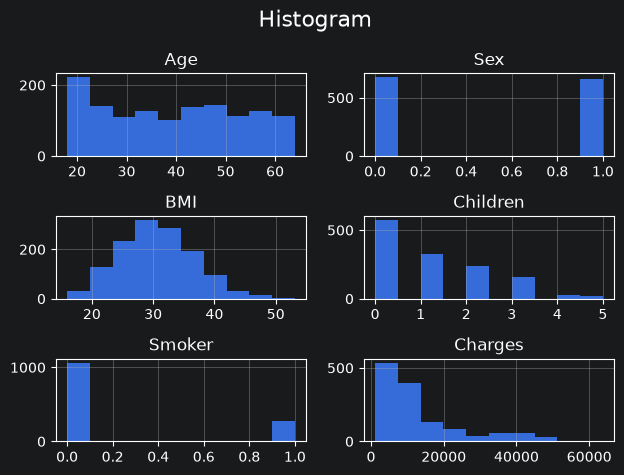

In [15]:
#Exploratory Data Analysis.
#Univariant:Histogram for distribution.
plt.figure(figsize=(15,8))#Set the size of the plot.
insurance.hist()
plt.suptitle('Histogram', fontsize=16)
plt.tight_layout()
plt.show()

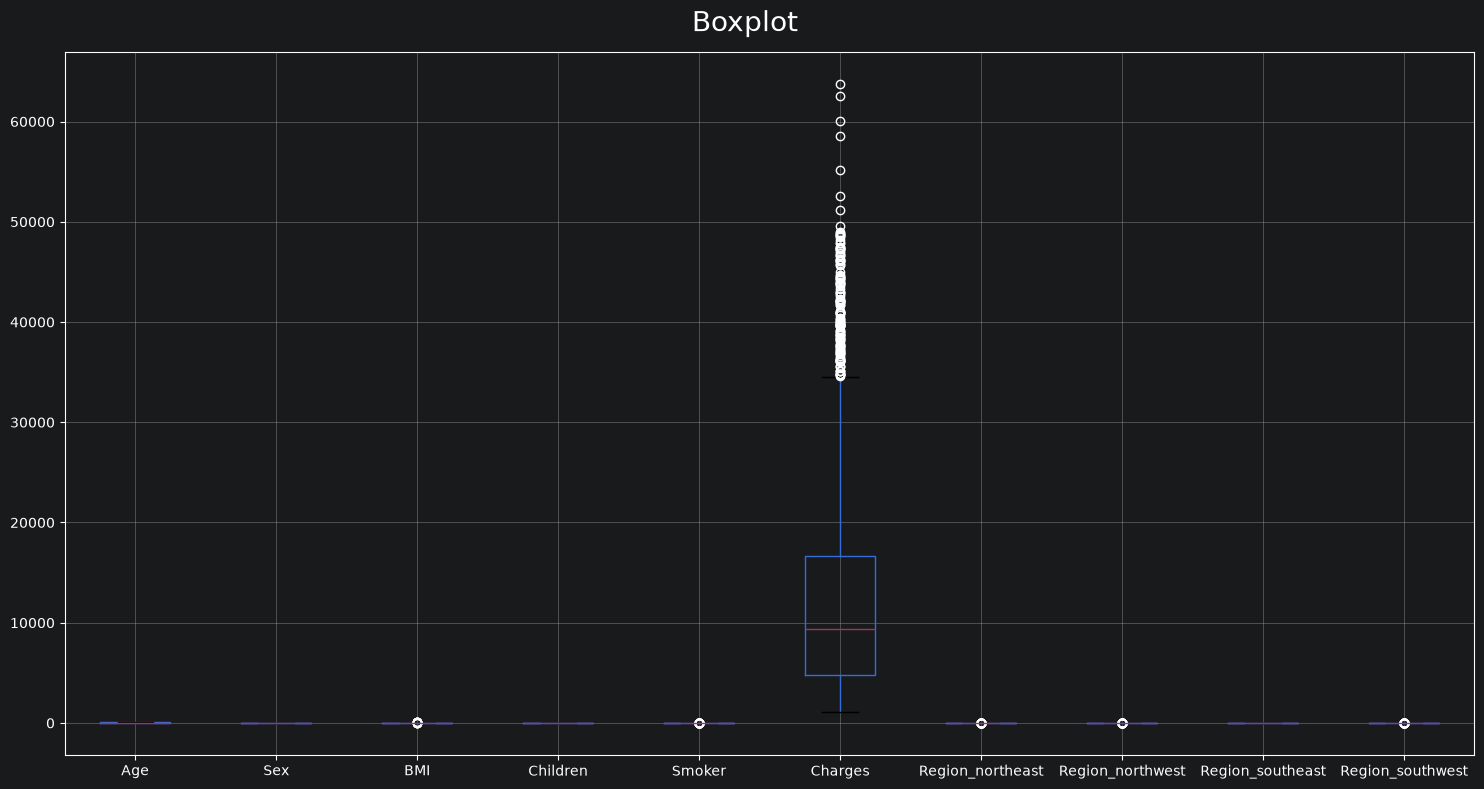

In [16]:
#Boxplot for Outliers: check reasons for outliers?
plt.figure(figsize=(15,8))#Set the size of the plot.
insurance.boxplot()
plt.suptitle('Boxplot', fontsize=20)
plt.tight_layout()
plt.show();


In [17]:
#Multivariant: correlation and heatmap for visualization.
corr = insurance.corr()#No need to print the corr as it can be visualized.

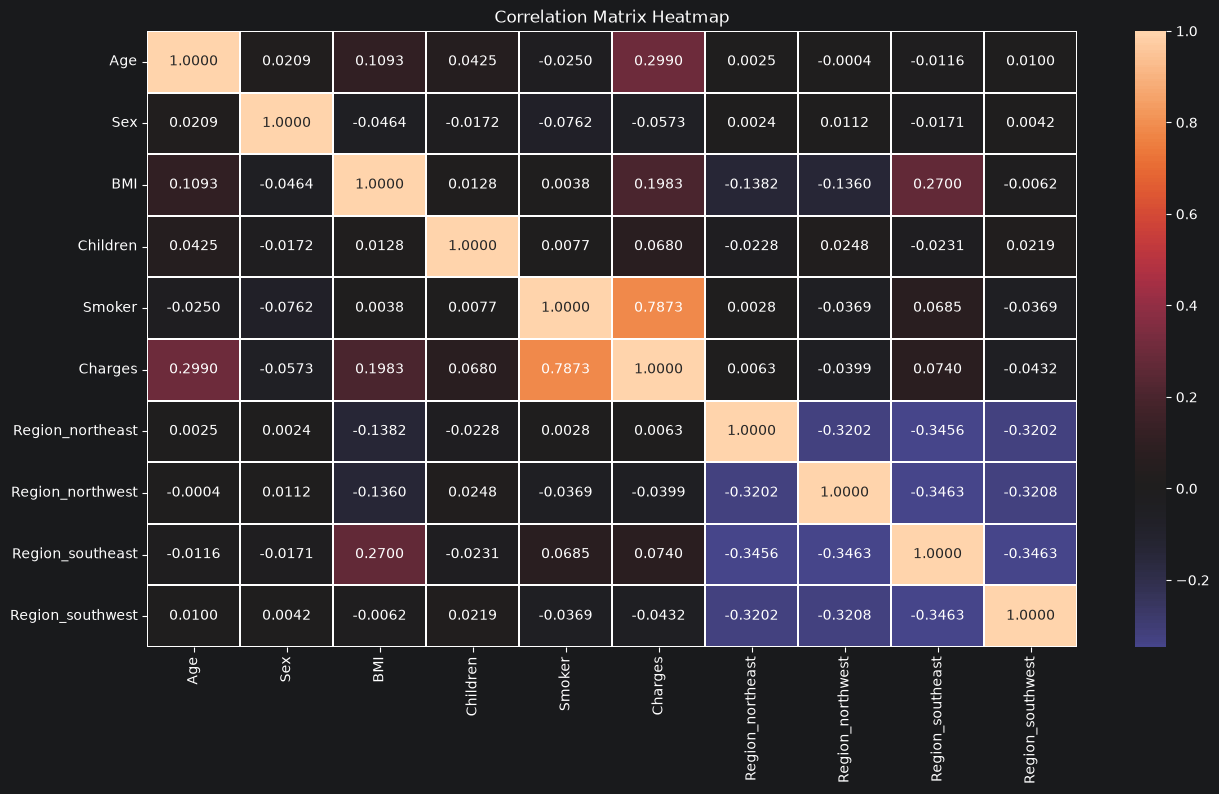

In [18]:
#Correlation heatmap: with my current level, will use correlation for independent variable selection(Age,bmi & smoker).
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, fmt='.4f', center=0,linewidths=.3)
plt.title('Correlation Matrix Heatmap')
plt.show();

In [19]:
'''Testing the pair plot.
from which module will I see the scatter_matrix for pair plot. From seaborn'''

'Testing the pair plot.\nfrom which module will I see the scatter_matrix for pair plot. From seaborn'

In [20]:
'''Save dataset to file.
insurance.write_to_csv'''

'Save dataset to file.\ninsurance.write_to_csv'

In [21]:
#Model training: import module
from sklearn.model_selection import train_test_split

In [22]:
insurance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1338 non-null   int64  
 1   Sex               1338 non-null   int64  
 2   BMI               1338 non-null   float64
 3   Children          1338 non-null   int64  
 4   Smoker            1338 non-null   int64  
 5   Charges           1338 non-null   float64
 6   Region_northeast  1338 non-null   bool   
 7   Region_northwest  1338 non-null   bool   
 8   Region_southeast  1338 non-null   bool   
 9   Region_southwest  1338 non-null   bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 68.1 KB


In [23]:
#Assign variables.

x = insurance.drop('Charges', axis = 1)
y = insurance['Charges']

#Split the dataset
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=42)

In [24]:
#Import the algorithm and name the model.
from sklearn.ensemble import RandomForestRegressor#don't understand from here down.
model = (RandomForestRegressor(n_estimators=100,random_state=42))
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [27]:
y_pred = model.predict(x_test)
print(y_pred)#Is this how it looks like?

[ 9807.4932   5333.3392  27996.5237  13023.2128  34671.8855   8383.1224
  2075.3618  14381.3687   6227.2549  10655.2632  19681.0031   7133.0347
  4696.9099  46243.8426  48448.5304  45700.6221   9963.1651  43517.0613
  9236.5649  24211.7397   6008.7592   9913.2847   1852.9054   2486.8361
 11964.8932  12255.0861  13388.9019   6148.2058  10346.4382   5799.7007
  7744.706   11726.3523   3481.6675   5542.1707   3377.5705  10670.0436
  2690.613    8192.9273  23500.1781  39475.1919   6395.3588   2882.4921
 12010.3943  14690.0618   5966.5325  14820.9621  15510.7375   5834.3571
 42101.6622   7053.2181  13941.9543   2758.2925   6655.3558   1833.2962
 13338.3272  10361.8011   3687.8504  45169.5726  12229.5145  15311.564
 13787.6297   7585.5921  20643.7112   7472.5029  12661.0839   5805.2338
 17627.2484  15306.9481   7744.7425   2543.9687   7689.218   10913.4345
  9290.1439  12783.9517   9138.1194   5115.0171   8344.4021  12785.6657
  4191.7457  10434.2752   2021.9957  27693.6635   6658.0965  3752

In [28]:
#Evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error,root_mean_squared_error

rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [29]:
#Display output
print(rmse)
print(mae)
print(r2)

4624.320327987735
2580.0313473134333
0.8622575659980845


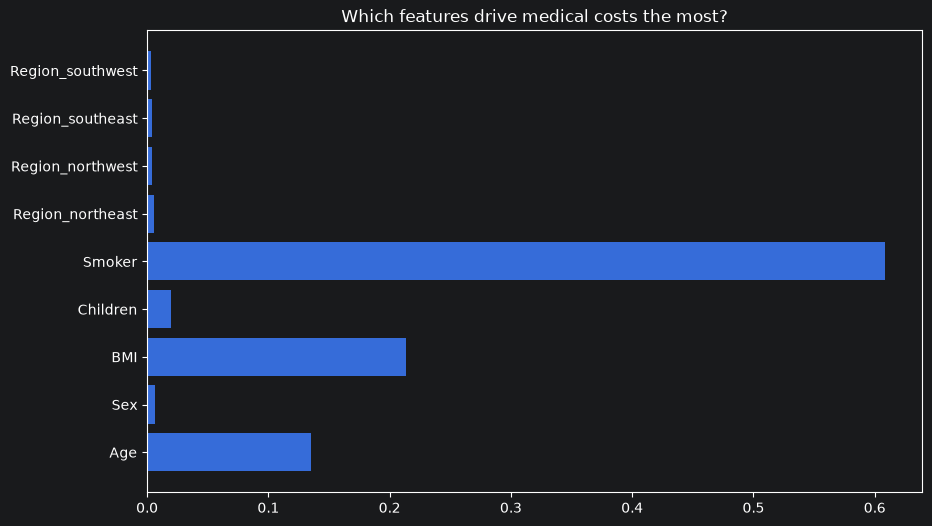

In [30]:
#Feature Importance: this information can also be gotten from the correlation matrix. Does it mean it can be used to cross-check the model? My correlation doesn't match with my feature.
importances = model.feature_importances_
feature_names = x.columns

# Visualize: a bit controversy here.
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Which features drive medical costs the most?")
plt.show()

In [90]:
#Blue-print of the work-flow on a new dataset.
# 1. Define new person data ie the input containing all the values needed as dictionary.
new_patient = {'Age': 22,
               'Sex': 'female',
               'BMI': 28.5,
               'Children': 0,
               'Smoker': 'no',
               'Region': 'southeast'}

# 2. Convert to a dataframe.
new_insurance = pd.DataFrame([new_patient])

# 3. Preprocess to match training data.
# Binary Mapping(Sex and Smoker)
new_insurance['Sex'] = new_insurance['Sex'].map({'female':1,'male':0})
new_insurance['Smoker'] = new_insurance['Smoker'].map({'no':0,'yes':1})

# One-hot encoding for region(matching the 4 columns from training)
new_insurance['Region_northeast'] = (new_insurance['Region'] == 'northeast')
new_insurance['Region_northwest'] = (new_insurance['Region'] == 'northwest')
new_insurance['Region_southeast'] = (new_insurance['Region'] == 'southeast')
new_insurance['Region_southwest'] = (new_insurance['Region'] == 'southwest')

# Drop the original region column so everything will rhyme with the training independent variables.
new_insurance = new_insurance.drop('Region', axis=1)

# 4. Make prediction on new dataset.
y_pred = model.predict(new_insurance)
print(f'Insurance Cost:${y_pred.round(2)}')

Insurance Cost:$[2458.76]


In [98]:
#Create function for the work-flow.
def insurance_quote(age,sex,bmi,children,smoker,region):
    # 1. Format the data into DataFrame
    input_data = pd.DataFrame([{'Age': age,
                               'Sex': sex,
                               'BMI': bmi,
                               'Children': children,
                               'Smoker': smoker,
                               'Region': region
                            }])
    # 2. Prepreocessing/Encoding
    input_data['Sex'] = input_data['Sex'].map({'female':1, 'male':0})
    input_data['Smoker'] = input_data['Smoker'].map({'no':0, 'yes':1})
    
    input_data['Region_northeast'] = (input_data['Region'] == 'northeast')
    input_data['Region_northwest'] = (input_data['Region'] == 'northwest')
    input_data['Region_southeast'] = (input_data['Region'] == 'southeast')
    input_data['Region_southwest'] = (input_data['Region'] == 'southwest')
    # 3. Drop the original region
    input_data = input_data.drop('Region', axis=1)
    # 4. Predict the cost
    y_pred = model.predict(input_data).round(2)
    return y_pred

In [100]:
#Call the function
insurance_cost = insurance_quote(35,'female',30,0,'yes','northeast')
print(insurance_cost)

[35038.19]


In [101]:
#Deploying of model
import joblib
joblib.dump(model,'Medical_Insurance_Cost.pkl')

['Medical_Insurance_Cost.pkl']